# Preliminary calculations: EU-DEMO 2018 baseline

In [31]:
# imports
using Symbolics, PrettyTables, DataFrames, LaTeXStrings
using Statistics
using CairoMakie
using Printf
using LsqFit, Optimization, OptimizationOptimJL, Roots, QuadGK
using Colors

Generate color palette and marker palette

In [32]:
color_palette = [
	RGB(0.0, 0.0, 0.0),  # Red
	RGB(0.9, 0.1, 0.1),  # Red
	RGB(0.1, 0.8, 0.5),  # Green
	RGB(0.1, 0.1, 0.9),  # Blue
	RGB(1.0, 0.9, 0.1),  # Yellow
	RGB(0.9, 0.1, 0.9)   # Magenta
];
marker_palette = [:circle, :rect, :utriangle, :cross, :diamond, :star8, :dtriangle];

Cross-section data - Reaction rates fitted to 100 keV

$\langle \sigma v \rangle [cm^3 s^{-1}] = A \cdot T^{-B} \cdot exp\left( -C \cdot T^{-D} \right)$

In [33]:
#Fit up to 100 keV
u_DD   = Float64[2.24642e-13, 0.739338, 21.1067, 0.306581];
u_DT   = Float64[3.35419e-7, 2.47828, 31.8505, 0.292999];
u_DHe3 = Float64[5.32595e-13 ,0.528691 ,31.4826 ,0.374262];
u_TT   = Float64[1.01487e-13 ,0.730876 ,19.5003 ,0.283029];
u_THe3 = Float64[2.20089e-10 ,1.2165 ,42.3469 ,0.30675];

#Fit up to 50 keV
#u_DD   = Float64[2.79402e-12, 1.06271,  23.6287, 0.287686];
#u_DT   = Float64[7.16584e-13, 0.701679, 18.7854, 0.409049];
#u_DHe3 = Float64[3.42613e-14, 0.105216, 28.7247, 0.395595];
#u_TT   = Float64[6.20204e-13, 1.0035,   21.3276, 0.27459];
#u_THe3 = Float64[3.53005e-9,  1.53138,  45.1148, 0.293664];

DataFrame(Params=["A","B","C","D"],
    D_D=u_DD,
	D_T=u_DT,
	D_He3=u_DHe3,
	T_T=u_TT,
	T_He3=u_THe3)

Row,Params,D_D,D_T,D_He3,T_T,T_He3
,String,Float64,Float64,Float64,Float64,Float64
1,A,2.24642e-13,3.35419e-7,5.32595e-13,1.01487e-13,2.20089e-10
2,B,0.739338,2.47828,0.528691,0.730876,1.2165
3,C,21.1067,31.8505,31.4826,19.5003,42.3469
4,D,0.306581,0.292999,0.374262,0.283029,0.30675


# Simulation parameters

In [34]:
n0::Float64 = 1.2e+20;    # ion density at the plasma center [m-3]
np::Float64 = 0.8e+20;    # [m-3]
a::Float64  = 2.826; 		  # minor radius [m]
R::Float64  = 8.76; 		  # major radius [m]
Δp::Float64 = 0.2; 		  # [m]
ap::Float64 = 2.8 - Δp;   # [m]
βt::Float64 = 6.0; 		  # just a parameter of the profile [-]
αt::Float64 = 8.06; 	  # just a parameter of the profile [-]
βn::Float64 = 2.0; 		  # just a parameter of the profile [-]
αn::Float64 = 1.0; 		  # just a parameter of the profile [-]
τE::Float64 = 4.0; 		  # confinement time [s]
Pfus::Float64 = 2.0;      # fusion power [GW]
Vplasma::Float64 = 2252.0 # plasma volume [m3]
Na::Float64 = 6.02214076e+23 # Avogadro number [mol-1]
k::Float64 = Vplasma / (2*pi*R * pi*a^2)

1.6307606518227502

## Temperature and density profiles

### $T_0 [keV]$ - temperature at the plasma center

In [35]:
T0 = 25.94 #PlutoUI.Slider(20.0:0.01:30.0, default=25.94, show_value=true)

25.94

### $T_p [keV]$ - temperature at the pedestel

In [36]:
Tp = 7.0 #PlutoUI.Slider(5.0:0.01:10.0, default=7.00, show_value=true)

7.0

### Density & Temperature distribution function

In [37]:
n(x) = @. np + (n0-np) * (1.0 - ((a/ap)^βn)*((x)^βn))^αn
T(x, T0) = @. Tp + (T0-Tp) * (1.0 - ((a/ap)^βt)*((x)^βt))^αt

T (generic function with 1 method)

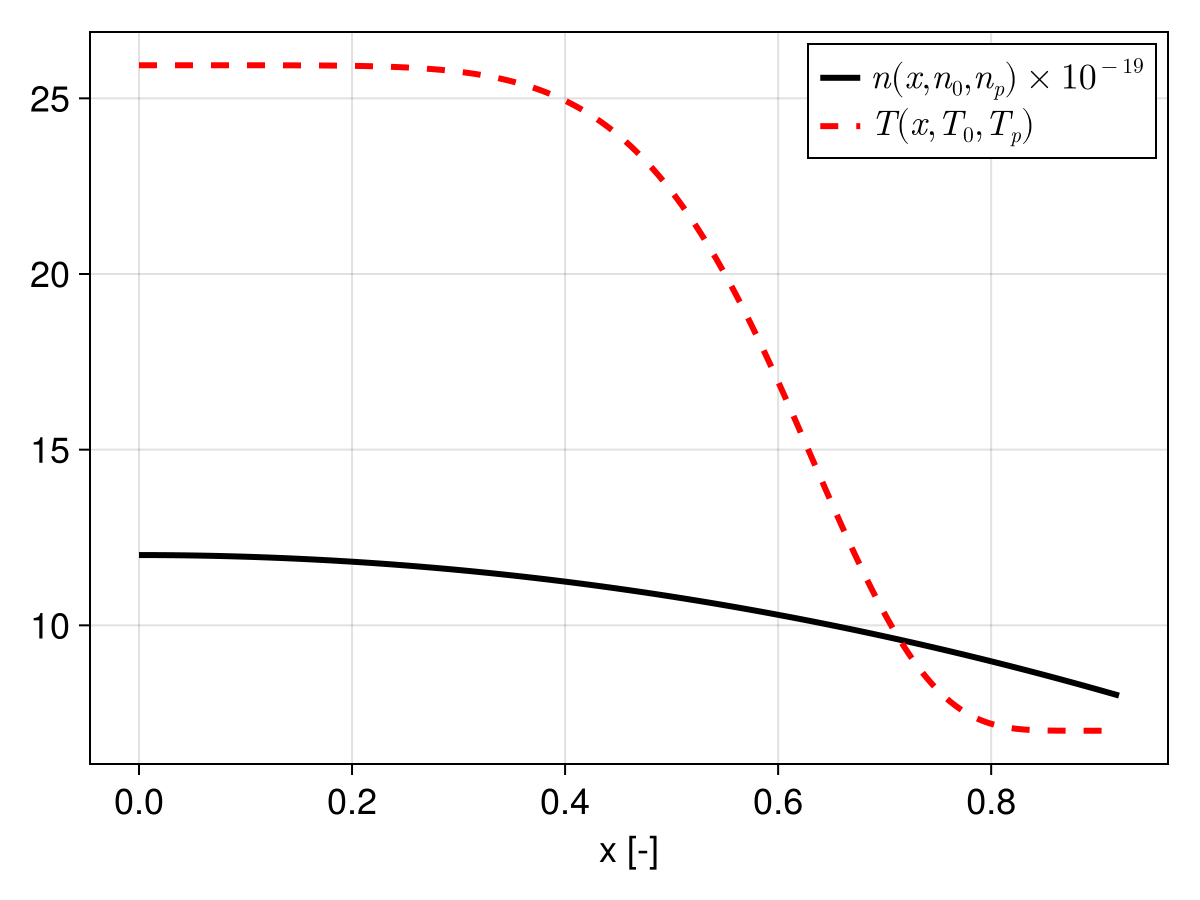

In [38]:
plotx = range(0.0, 0.92, length=1000)

fig1 = Figure(fontsize=18)
ax1 = Axis(fig1[1, 1], xlabel="x [-]", )
lines!(ax1, plotx, n(plotx)*1e-19, label=L"n(x,n_0,n_p) \times 10^{-19}", linewidth=3, color=:black, linestyle=:solid)
lines!(ax1, plotx, T(plotx, T0), label=L"T(x,T_0,T_p)", linewidth=3, color=:red, linestyle=:dash)
axislegend(position = :rt)
fig1

In [39]:
save("n_T_profiles.png", fig1)

#### Let's plug the temperature distribution into the Reaction rates

In [40]:
σv_DD(x)   = @. u_DD[1] * T(x,T0)^(-u_DD[2]) * exp(-u_DD[3] * T(x,T0)^(-u_DD[4])) *1.0e-6 # [m3 s-1]
σv_DD_paper(x) = @. 2.33e-14 * T(x,T0)^(-2/3) * exp(-18.76 * T(x,T0)^(-1/3)) * 1.0e-6 # [m3 s-1]
σv_DT_paper(x,T0) = @. 3.68e-12 * T(x,T0)^(-2/3) * exp(-19.94 * T(x,T0)^(-1/3)) * 1.0e-6 # [m3 s-1]
σv_DT(x,T0)   = @. u_DT[1] * T(x,T0)^(-u_DT[2]) * exp(-u_DT[3] * T(x,T0)^(-u_DT[4]))  *1.0e-6 # [m3 s-1]
σv_DHe3(x) = @. u_DHe3[1] * T(x,T0)^(-u_DHe3[2]) * exp(-u_DHe3[3] * T(x,T0)^(-u_DHe3[4]))  *1.0e-6 # [m3 s-1]
σv_TT(x)   = @. u_TT[1] * T(x,T0)^(-u_TT[2]) * exp(-u_TT[3] * T(x,T0)^(-u_TT[4]))  *1.0e-6 # [m3 s-1]
σv_THe3(x) = @. u_THe3[1] * T(x,T0)^(-u_THe3[2]) * exp(-u_THe3[3] * T(x,T0)^(-u_THe3[4]))  *1.0e-6 # [m3 s-1]

σv_THe3 (generic function with 1 method)

## Hydrogen outgassing
References:
- Schram, Le Vide (1963) - Desorption in vacuum
- Ishikawa (2003) - An overview of methods to suppress hydrogen outgassing rate from austenitic steel with reference to UHV and EXV

In [41]:
display("text/markdown", """
**Ishikawa:**
- Values from Table 1: \$4\\times 10^{-12}\\ - 3\\times 10^{-16} [\\mathrm{mbar\\ l\\ s^{-1}\\ cm^{-2}}]\$
- Converion factor to SI: \$1\\cdot [\\mathrm{mbar\\ l\\ s^{-1}\\ cm^{-2}}] = \\mathrm{\\frac{100 Pa\\ 10^{-3} m^3}{s^{-1}\\ 10^{-4}m^{-2}}} = 1000\\cdot [\\mathrm{Pa\\ m^3\\ s^{-1}\\ m^{-2}}]\$
- range = \$4\\times 10^{-9}\\ - 3\\times 10^{-13} [\\mathrm{Pa\\ m^3\\ s^{-1}\\ m^{-2}}]\$
- range = $(round(4e-9*2/(8.314*273.15), sigdigits=4)) - $(round(3e-13*2/(8.314*273.15), sigdigits=4)) [gH s-1 m-2]
- range = $(round(4e-9*2*Na/(8.314*273.15), sigdigits=4)) - $(round(3e-13*2*Na/(8.314*273.15), sigdigits=4)) [particles s-1 m-2]

**Schram, Le Vide:**
- Values from  Fig.5: \$47\\times 10^{10}\\ - 0.2\\times 10^{10} [\\mathrm{particles\\ s^{-1}\\ cm^{-2}}]\$
- Converion factor to SI: \$1\\cdot [\\mathrm{particles\\ s^{-1}\\ cm^{-2}}] = 1\\times 10^4 [\\mathrm{particles\\ s^{-1}\\ m^{-2}}]\$
- range = \$47\\times 10^{14}\\ - 0.2\\times 10^{14} [\\mathrm{particles\\ s^{-1}\\ m^{-2}}]\$
- range = $(round(47e14/Na, sigdigits=4)) - $(round(0.2e14/Na, sigdigits=4)) [molH s-1 m-2] = [gH s-1 m-2]
- range = $(round(47e14*8.314*273.15/(Na*2), sigdigits=4)) - $(round(0.2e14*8.314*273.15/(Na*2), sigdigits=4)) [Pa m3 s-1 m-2]

""")

**Ishikawa:**
- Values from Table 1: $4\times 10^{-12}\ - 3\times 10^{-16} [\mathrm{mbar\ l\ s^{-1}\ cm^{-2}}]$
- Converion factor to SI: $1\cdot [\mathrm{mbar\ l\ s^{-1}\ cm^{-2}}] = \mathrm{\frac{100 Pa\ 10^{-3} m^3}{s^{-1}\ 10^{-4}m^{-2}}} = 1000\cdot [\mathrm{Pa\ m^3\ s^{-1}\ m^{-2}}]$
- range = $4\times 10^{-9}\ - 3\times 10^{-13} [\mathrm{Pa\ m^3\ s^{-1}\ m^{-2}}]$
- range = 3.523e-12 - 2.642e-16 [gH s-1 m-2]
- range = 2.121e12 - 1.591e8 [particles s-1 m-2]

**Schram, Le Vide:**
- Values from  Fig.5: $47\times 10^{10}\ - 0.2\times 10^{10} [\mathrm{particles\ s^{-1}\ cm^{-2}}]$
- Converion factor to SI: $1\cdot [\mathrm{particles\ s^{-1}\ cm^{-2}}] = 1\times 10^4 [\mathrm{particles\ s^{-1}\ m^{-2}}]$
- range = $47\times 10^{14}\ - 0.2\times 10^{14} [\mathrm{particles\ s^{-1}\ m^{-2}}]$
- range = 7.805e-9 - 3.321e-11 [molH s-1 m-2] = [gH s-1 m-2]
- range = 8.862e-6 - 3.771e-8 [Pa m3 s-1 m-2]



# Active Zone (AZ) calculation

## Method 1) Active Zone calculation: use the definition of the fusion power with the integral formulation to fin $r_{az} [m]$

In [42]:
tmp1(u) = @. (n(u)^2) * σv_DT_paper(u,T0) * u
Efus = 17.6e+6 / (6.2415e+18 * 1.0e+9) # [GW] from MeV to GW
RHS(x) = @. quadgk(tmp1, 0, x)[1] * (Efus * pi^2 * R * k * a^2)

RHS (generic function with 1 method)

Find the intercept

In [43]:
xz_root(x) = @. Pfus - RHS(x)
x_az = find_zero(xz_root, 0.6)  # Start the search near x = 0.7
r_az = x_az * a
println("x_az, Method 3) = ",x_az)
println("r_az, Method 3) = ",r_az)

x_az, Method 3) = 0.44126992217744293
r_az, Method 3) = 1.2470288000734537


In [44]:
Vaz = Vplasma * (r_az / a)^2
Vplasma_computed = 2 * pi^2 * R * a^2 * k #*1.01869
println("Vaz, as Vplasma*(r_az/a)^2 = ", Vaz)
println("Vaz, as (2 pi R)*(pi k r^2) = ", 2 * pi * R * pi * k * r_az^2)
println("Vplasma computed = ",Vplasma_computed)
println("Vplasma input = ",Vplasma)

Vaz, as Vplasma*(r_az/a)^2 = 438.5075127800317
Vaz, as (2 pi R)*(pi k r^2) = 438.50751278003173
Vplasma computed = 2252.0
Vplasma input = 2252.0


# Protium production calculation

## integrate all the reactions that produce protium

$\Gamma [s-1] = \frac{1}{4}\ (2\pi R)\ (2 \pi k a^2) \int_{0}^{x_{az}} \Phi(x) x \,dx$

In [45]:
intArg_DD(u)   = @. 0.5 * (n(u)^2) * σv_DD(u) * u
intArg_DHe3(u) = @. intArg_DD(u) * σv_DHe3(u)
intArg_THe3(u) = @. (0.51+0.06) * intArg_DD(u) * σv_THe3(u)

intArg2_DD(u)   = @. 0.5 * (n(u/a)^2) * σv_DD(u/a) * u
intArg2_DHe3(u) = @. intArg2_DD(u) * σv_DHe3(u/a)
intArg2_THe3(u) = @. (0.51+0.06) * intArg2_DD(u) * σv_THe3(u/a)

# Integration of the reaction rates over the whole torus
# we multiply for the toroidal length, 2*pi*R, and we integrate over the poloidal cross sectional area: 2*pi*int(f(x)*x dx)
Γ_DD(x)   = @. k * a^2 * R * (pi^2) * quadgk(intArg_DD, 0, x)[1]
Γ_DHe3(x) = @. k * a^2 * R * (pi^2) * quadgk(intArg_DHe3, 0, x)[1]
Γ_THe3(x) = @. k * a^2 * R * (pi^2) * quadgk(intArg_THe3, 0, x)[1]

Γ2_DD(r)   = @. k * R * (pi^2) * quadgk(intArg2_DD, 0, r)[1]
Γ2_DHe3(r) = @. k * R * (pi^2) * quadgk(intArg2_DHe3, 0, r)[1]
Γ2_THe3(r) = @. k * R * (pi^2) * quadgk(intArg2_THe3, 0, r)[1]


Γ2_THe3 (generic function with 1 method)

Let's compute the integral up to the active zone coordinate

Γ [s-1]: H atoms produced each second.

In [ ]:
Γ_tot = Γ_DD(x_az) + Γ_DHe3(x_az) + Γ_THe3(x_az)
Γ2_tot = Γ2_DD(r_az) + Γ2_DHe3(r_az) + Γ2_THe3(r_az)
Γ_DD(x_az)
Γ_DHe3(x_az)
Γ_THe3(x_az)

# G [g/s] = Γ / Na
G_tot = Γ_tot / Na

# G_DD [g/s] = Γ_DD / Na
G_DD = Γ_DD(x_az) / Na

### Active zone radius:
#### - r-az = $(round(r_az, digits = 4)) [m]
#### - x-az = $(round(r_az/a, digits = 4)) [-]
### Protium production:
#### - Γ = $(round(G_tot, sigdigits = 4)) [g/s]

# SENSITIVITIES

## Evaluate active zone as a function of plasma core temperature $T0$. x is the normalized minor radius. The point where the Right Hand Side ("RHS") curve crosses the reactor fusion power ("Pfus DEMO") is the active zone normalized radius.

┌ Warning: `arrows` are deprecated in favor of `arrows2d` and `arrows3d`.
└ @ Makie /home/fe/.julia/packages/Makie/Vn16E/src/basic_recipes/arrows.jl:166
┌ Warning: arrowsize has been deprecated in favor of tipwidth and tiplength.
└ @ Makie /home/fe/.julia/packages/Makie/Vn16E/src/basic_recipes/arrows.jl:206


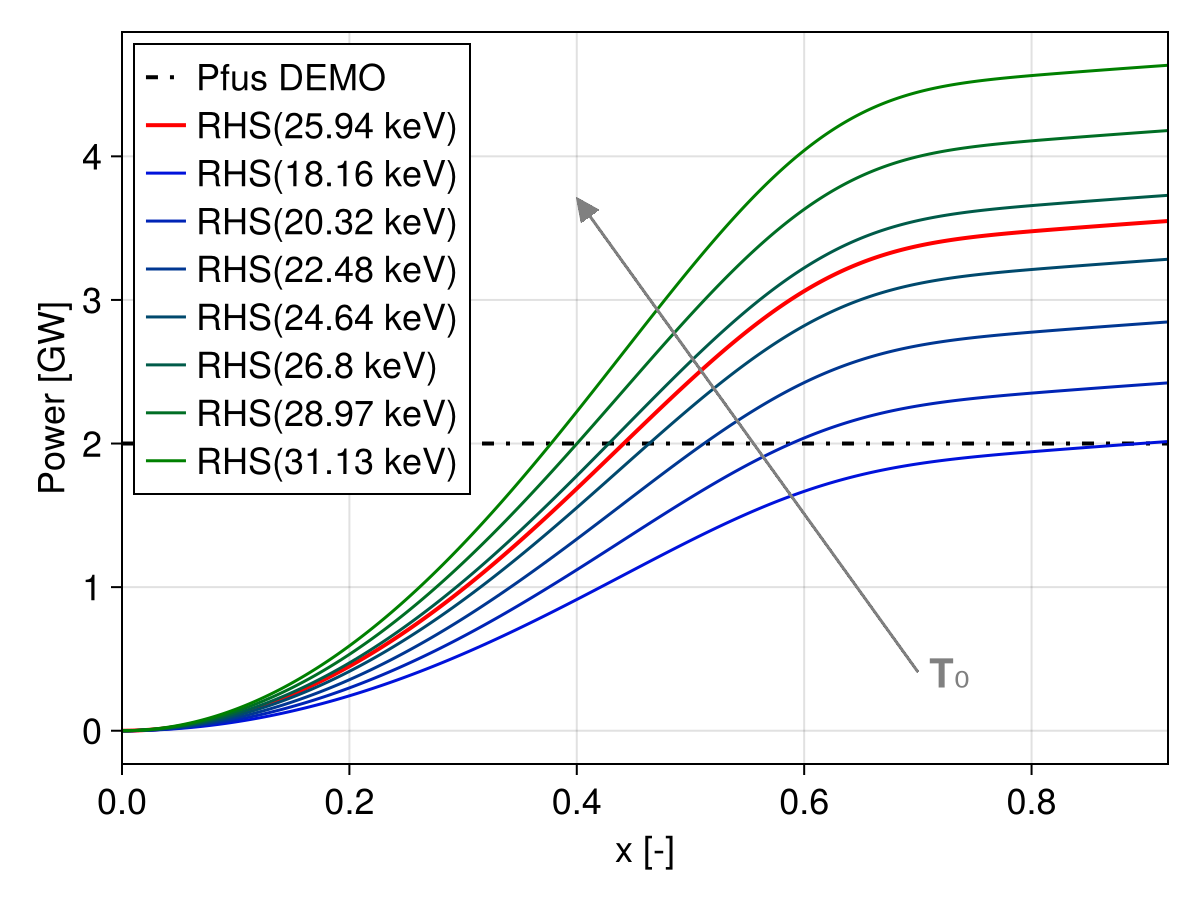

In [47]:
T0_values = range(T0*0.7, T0*1.2, length=7) # Create 5 values of T0
color_gradient = cgrad([:blue, :green]) # Create a gradient from blue to red
n_lines = length(T0_values) # Number of lines

fig4 = Figure(fontsize=18)
ax4 = Axis(fig4[1, 1], xlabel="x [-]", ylabel="Power [GW]", limits=(plotx[1], plotx[end],nothing,nothing))

lines!(ax4, plotx, fill(Pfus, length(plotx)), label="Pfus DEMO", linestyle=:dashdot, color=:black, linewidth=2)
lines!(ax4, plotx, RHS.(plotx), label="RHS($T0 keV)",  color=:red, linestyle=:solid, linewidth=2)
for (i,T0_i) in enumerate(T0_values)
	line_color = color_gradient[i / n_lines]  # Normalize index to range [0, 1]
	tmp_i(u) =  @. (n(u)^2) * σv_DT_paper(u,T0_i) * u
	RHS_i(x) =  @. quadgk(tmp_i, 0, x)[1] * (Efus * pi^2 * R * k * a^2)
    lines!(ax4, plotx, RHS_i.(plotx), label="RHS($(round(T0_i, sigdigits = 4)) keV)", color=line_color)
end
arrows!(ax4, [Point(0.7, 0.41)], [Point(-0.3, 3.3)]; color=:gray, linewidth=3, arrowsize = 15)
text!(ax4, 0.71, 0.40, text = "T₀", align = (:left, :center), color=:gray, font=:bold, fontsize=20)
axislegend(position = :lt)

save("T0_sens_on_x_az.png", fig4)
fig4

## Evaluate the effect of the coefficients of the density (αn, βn) and temperature (αt, βt) profiles on the protium production rate.

Redefine n, T and σv as a function of x, α and β

In [48]:
nₛ(x,αnₛ,βnₛ) = @. np + (n0-np) * (1.0 - ((a/ap)^βnₛ)*((x)^βnₛ))^αnₛ
Tₛ(x,αtₛ,βtₛ) = @. Tp + (T0-Tp) * (1.0 - ((a/ap)^βtₛ)*((x)^βtₛ))^αtₛ

σv_DDₛ(x,αtₛ,βtₛ) = @. u_DD[1] * Tₛ(x,αtₛ,βtₛ)^(-u_DD[2]) * exp(-u_DD[3] * Tₛ(x,αtₛ,βtₛ)^(-u_DD[4])) *1.0e-6 # [m3 s-1]
σv_DTₛ(x,αtₛ,βtₛ) = @. u_DT[1] * Tₛ(x,αtₛ,βtₛ)^(-u_DT[2]) * exp(-u_DT[3] * Tₛ(x,αtₛ,βtₛ)^(-u_DT[4])) *1.0e-6 # [m3 s-1]
σv_DHe3ₛ(x,αtₛ,βtₛ) = @. u_DHe3[1] * Tₛ(x,αtₛ,βtₛ)^(-u_DHe3[2]) * exp(-u_DHe3[3] * Tₛ(x,αtₛ,βtₛ)^(-u_DHe3[4])) *1.0e-6 # [m3 s-1]
σv_THe3ₛ(x,αtₛ,βtₛ) = @. u_THe3[1] * Tₛ(x,αtₛ,βtₛ)^(-u_THe3[2]) * exp(-u_THe3[3] * Tₛ(x,αtₛ,βtₛ)^(-u_THe3[4])) *1.0e-6 # [m3 s-1]
σv_TTₛ(x,αtₛ,βtₛ) = @. u_TT[1] * Tₛ(x,αtₛ,βtₛ)^(-u_TT[2]) * exp(-u_TT[3] * Tₛ(x,αtₛ,βtₛ)^(-u_TT[4])) *1.0e-6 # [m3 s-1]

σv_TTₛ (generic function with 1 method)

Define the arguments for the integral for finding x_az

In [49]:
tmp_Tₛ(u,αtₛ,βtₛ) = @. (n(u)^2) * σv_DTₛ(u,αtₛ,βtₛ) * u

tmp_Tₛ (generic function with 1 method)

Compute the RHS of the equation Pfus = Efus * 2piR * int(0.25 * n^2 * σv * 2pir dr)

In [50]:
RHS_Tₛ(x,αtₛ,βtₛ) = @. quadgk(x -> tmp_Tₛ(x,αtₛ,βtₛ), 0, x)[1] * (Efus * pi^2 * R * k * a^2)

RHS_Tₛ (generic function with 1 method)

Create the functions for the root finding, to find x_az

In [51]:
function parametric_x_az_t(αtₛ, βtₛ)
    temp12(x) = @. Pfus - RHS_Tₛ(x, αtₛ, βtₛ)  # Equation to solve
    return find_zero(temp12, 0.6)  # Initial guess for x is 0.6
end

parametric_x_az_t (generic function with 1 method)

Plot the sensitivites of the exponents for n and T, play with the length of the range used in the sensitivity

In [52]:
# n_values - number of values to use in the profiles sensitivity
n_values = 11 #@bind n_values PlutoUI.Slider(1:1:20, default=11, show_value=true)

11

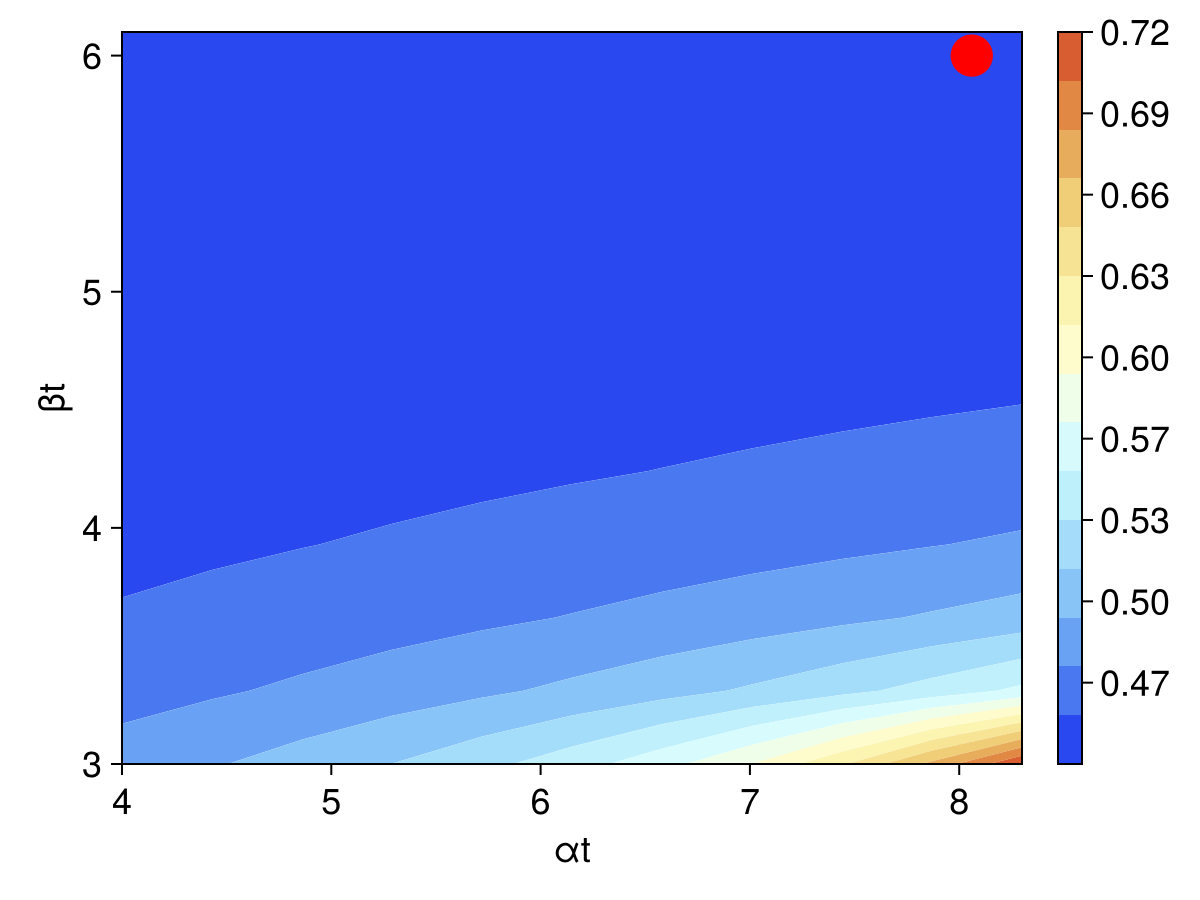

In [53]:
αt_values = range(4.0, 8.3, length=n_values); # 8.06
βt_values = range(3.0, 6.1, length=n_values); # 6.0
myz = [parametric_x_az_t(x,y) for x in αt_values, y in βt_values] 

fig = Figure(fontsize=18)
ax = Axis(fig[1,1], xlabel = "αt", ylabel = "βt") #, title="Normalized active zone radius [-]")

hm = contourf!(ax, αt_values, βt_values, myz; levels=15, colormap=:lighttemperaturemap)
Colorbar(fig[1, 2], hm, ticks = range(minimum(myz), maximum(myz), length = 10), tickformat = "{:.2f}")
scatter!(ax, 8.06, 6.0, marker=:circle, markersize=30, color=:red)
save("T_profile_sens.png", fig)
fig

## Evaluate the protium production rate [g/s] as a function of T0 (core plasma temperature) and the active zone radius x_az.

Define σv(x,T0). I need only DD, DHe3, THe3.

In [55]:
σv_DDₛ(x,T0)   = @. u_DD[1] * T(x,T0)^(-u_DD[2]) * exp(-u_DD[3] * T(x,T0)^(-u_DD[4])) *1.0e-6 # [m3 s-1]
σv_DHe3ₛ(x,T0) = @. u_DHe3[1] * T(x,T0)^(-u_DHe3[2]) * exp(-u_DHe3[3] * T(x,T0)^(-u_DHe3[4])) *1.0e-6 # [m3 s-1]
σv_THe3ₛ(x,T0) = @. u_THe3[1] * T(x,T0)^(-u_THe3[2]) * exp(-u_THe3[3] * T(x,T0)^(-u_THe3[4])) *1.0e-6 # [m3 s-1]

σv_THe3ₛ (generic function with 2 methods)

Define integral arguments as a function of x and T0

In [56]:
intArg_DDₛ(u,T0)   = @. 0.5 * (n(u)^2) * σv_DDₛ(u,T0) * u
intArg_DHe3ₛ(u,T0) = @. intArg_DDₛ(u,T0) * σv_DHe3ₛ(u,T0)
intArg_THe3ₛ(u,T0) = @. (0.51+0.06) * intArg_DDₛ(u,T0) * σv_THe3ₛ(u,T0)

intArg_THe3ₛ (generic function with 1 method)

Integrate the reaction rate over the poloidal cross section and over the major radius

In [57]:
Γ_DDₛ(x,T0)   = @. k * a^2 * R * (pi^2) * quadgk(x -> intArg_DDₛ(x, T0), 0, x)[1]
Γ_DHe3ₛ(x,T0) = @. k * a^2 * R * (pi^2) * quadgk(x -> intArg_DHe3ₛ(x, T0), 0, x)[1]
Γ_THe3ₛ(x,T0) = @. k * a^2 * R * (pi^2) * quadgk(x -> intArg_THe3ₛ(x, T0), 0, x)[1]

Γ_THe3ₛ (generic function with 1 method)

Define the final production rate function, to be used in the contour plot

In [58]:
G_totₛ(x,T0) = @. ( Γ_DDₛ(x,T0) + Γ_DHe3ₛ(x,T0) + Γ_THe3ₛ(x,T0) ) / Na
G_totₛ(x_az,T0)

9.98776130033218e-6

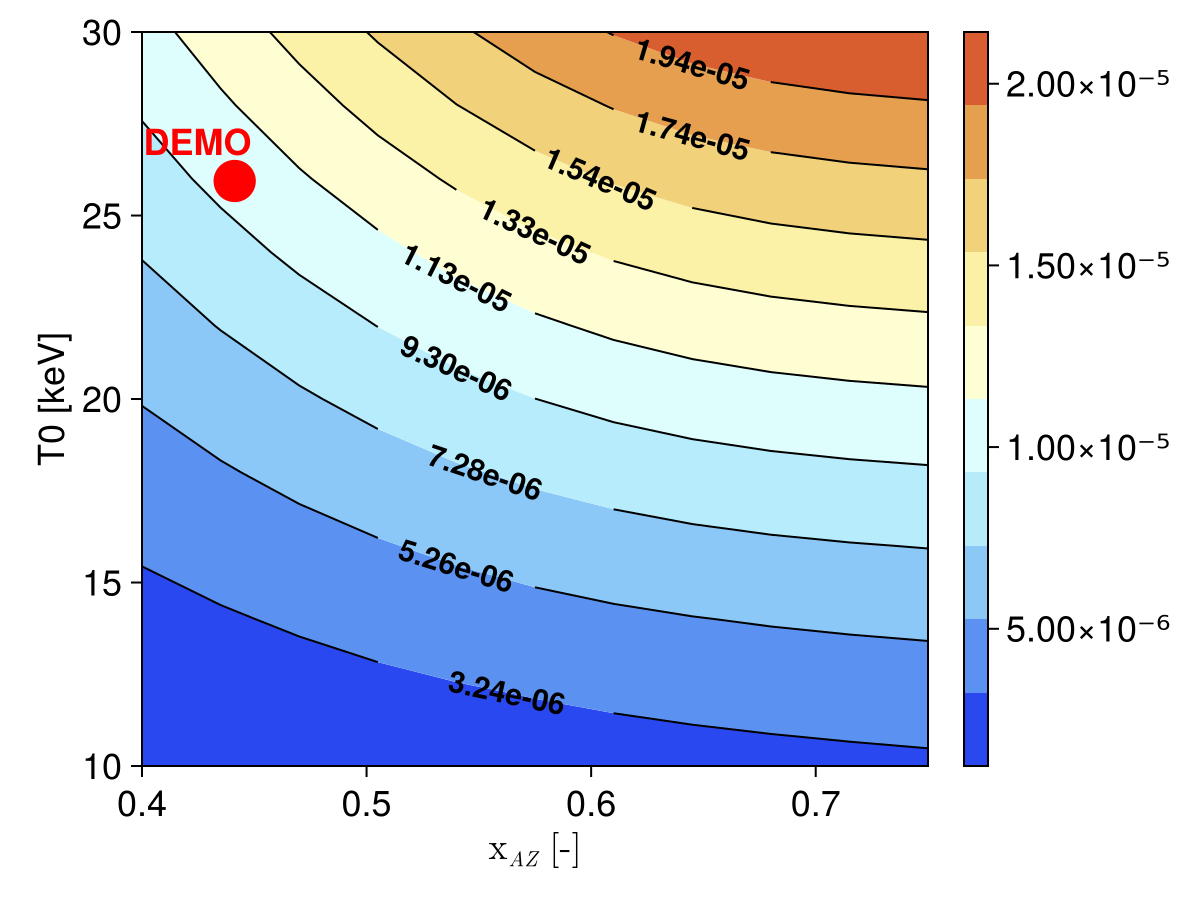

In [59]:
x = range(0.4, 0.75, length=n_values)
y = range(10.0, 30.0, length=n_values)
z = [G_totₛ(x,y) for x in x, y in y]

f = Figure(fontsize=18)
ax = Axis(f[1,1], xlabel = L"x$_{AZ}$ [-]", ylabel = "T0 [keV]",
		  ytickformat = "{:.0f}",
	      # title="Protium production [g s-1]"
	      # yticklabelsize=15, 
		  # xticklabelsize=15
		  )

hm = contourf!(ax, x, y, z; colormap=:lighttemperaturemap)
Colorbar(f[1, 2], hm 
	     # ticklabelsize=15
        )

contour!(ax, x, y, z;
  		 color = :black, labels = true, levels=9, 
		 labelsize = 15, 
		 labelfont = :bold, labelcolor = :black,
         labelformatter = x -> @sprintf("%.2e", x))

scatter!(ax, x_az, T0, marker=:circle, markersize=30, color=:red)
text!(ax, x_az*1.017, T0*1.041, text = "DEMO", align = (:right, :center), color=:red, font=:bold)

save("H_production.png", f)
f

# Ignition temperature analysis

In [60]:
navg = quadgk(n, 0, 1.0)[1] / (1.0 - 0.0)
Ttemp(x) = T(x,T0)
Tavg = quadgk(Ttemp, 0, 0.92)[1] / (0.92 - 0.0)
σv_DT(T) = u_DT[1] * T^(-u_DT[2]) * exp(-u_DT[3] * T^(-u_DT[4])) * 1.0e-6 # [m3 s-1]
nτ(T) = @. 12 * T * 0.001 / (σv_DT(T) * 3.5)
Trange = range(2.0, 200.0, length=1000)

2.0:0.1981981981981982:200.0

In [62]:
F1(x) = @. τE * n(x)
F2_DT(x) = @. 12.0 * T(x, T0) / (σv_DT(x, T0) * 3500.0)
F2DT_paper(x) = @. 12.0 * T(x, T0) / (sigmav_DT_paper(x) * 3500.0)

F2DT_paper (generic function with 1 method)

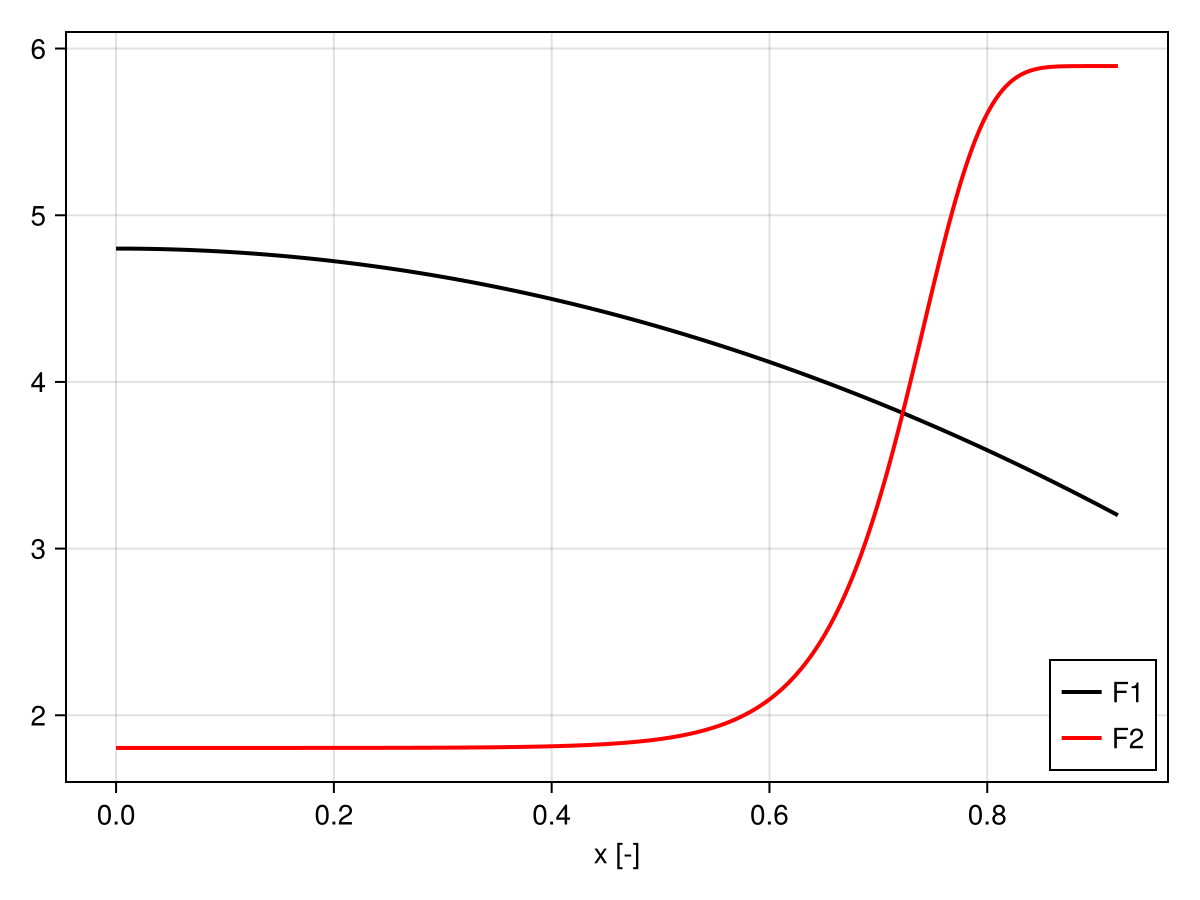

In [63]:
fig = Figure()
ax = Axis(fig[1,1], xlabel="x [-]")
lines!(ax, plotx, F1(plotx)/1e20, label="F1", color=:black, linewidth=2)
lines!(ax, plotx, F2_DT(plotx)/1e20, label="F2", color=:red, linewidth=2)
axislegend(position=:rb)
fig

In [64]:
F1F2rootf(x) = F1(x) - F2_DT(x)
# Normalized poloidal radius that marks the end of the active zone [m]
x_az_1 = find_zero(F1F2rootf, 0.6) 
# Poloidal radius that marks the end of the active zone [m]
r_az_1 = x_az_1 * a
print("x_az, method 1) = ", x_az_1)

x_az, method 1) = 0.7223967924954269

In [69]:
tmp_nₛ(u,αnₛ,βnₛ) = @. (nₛ(u,αnₛ,βnₛ)^2) * σv_DT(u,T0) * u
RHS_nₛ(x,αnₛ,βnₛ) = @. quadgk(x -> tmp_nₛ(x,αnₛ,βnₛ), 0, x)[1] * (Efus * pi^2 * R * k * a^2)

RHS_nₛ (generic function with 1 method)

In [71]:
function parametric_x_az_n(αnₛ, βnₛ)
    temp(x) = @. Pfus - RHS_nₛ(x, αnₛ, βnₛ)  # Equation to solve
    return find_zero(temp, 0.6)  # Initial guess for x is 0.6
end

parametric_x_az_n (generic function with 1 method)

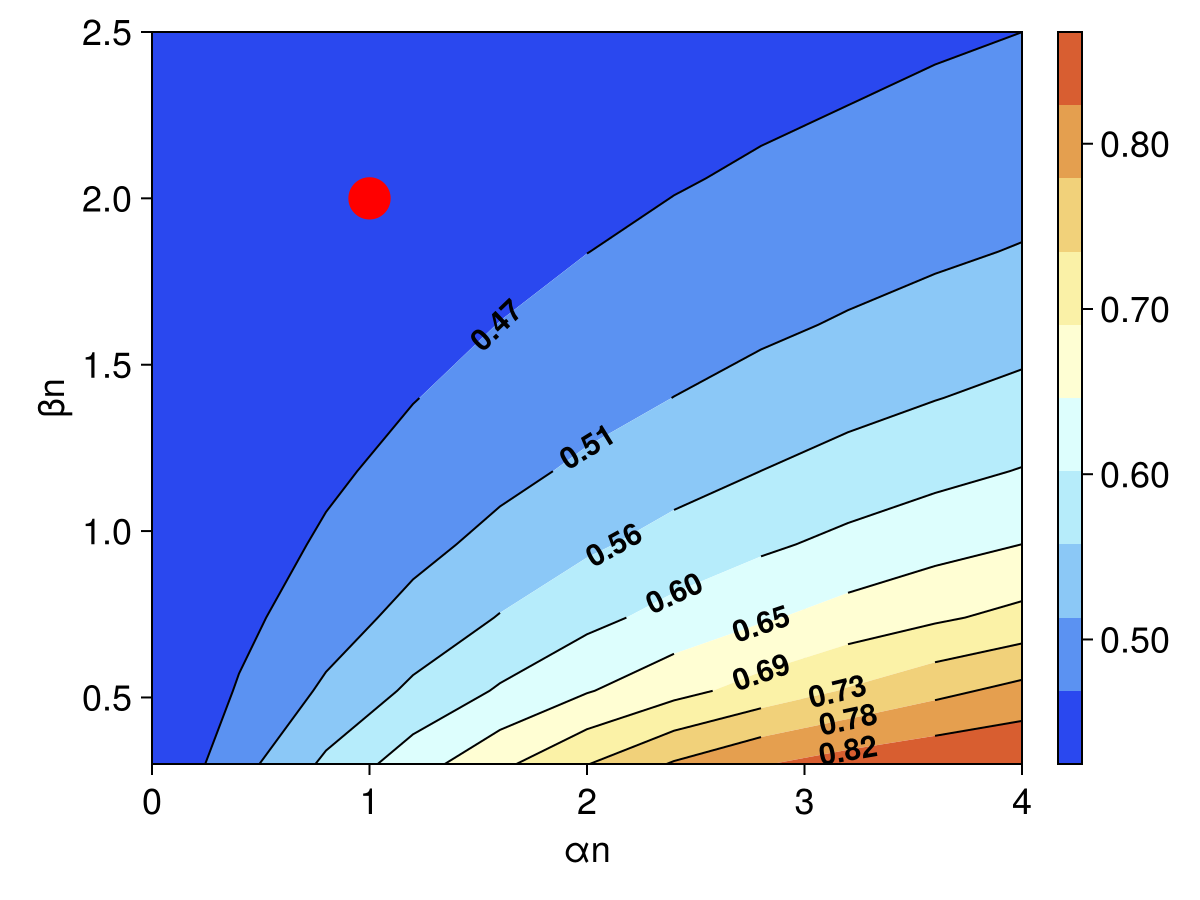

In [72]:
αn_values = range(0.0, 4.0, length=n_values); # 1.0
βn_values = range(0.3, 2.5, length=n_values); # 2.0

f = Figure(fontsize=18)
ax = Axis(f[1,1], xlabel = "αn", ylabel = "βn") #, title="Normalized active zone radius [-]")

hm = contourf!(ax, αn_values, βn_values, parametric_x_az_n;
                colormap=:lighttemperaturemap)
Colorbar(f[1, 2], hm, tickformat = "{:.2f}")

contour!(ax, αn_values, βn_values, parametric_x_az_n;
  		 color = :black, labels = true, levels=9, 
		 labelsize = 15, 
		 labelfont = :bold, labelcolor = :black,
         labelformatter = x -> @sprintf("%.2f", x))

scatter!(ax, 1.0, 2.0, marker=:circle, markersize=30, color=:red)
save("n_profile_sens.png", f)
f

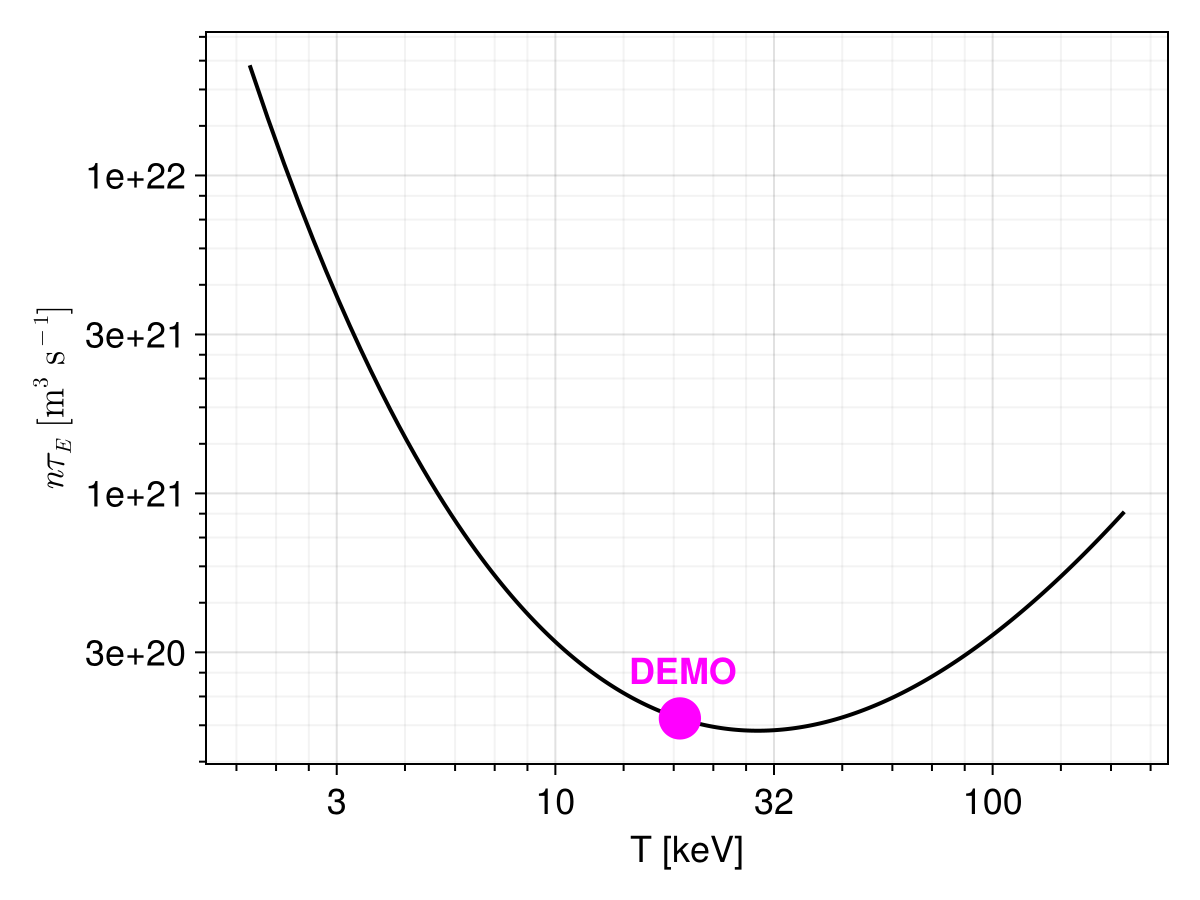

In [73]:
f = Figure(fontsize=18)
ax = Axis(f[1,1], ylabel = L"$n \tau_E$ \mathrm{[$m^3\ s^{-1}$]}", xlabel = "T [keV]", 
	       yscale= log10, xscale= log10, xtickformat = "{:.0f}", ytickformat = "{:.0e}",
		   xminorgridvisible = true, xminorticksvisible = true,
		   yminorgridvisible = true, yminorticksvisible = true,
		   xminorticks = IntervalsBetween(5),
		   yminorticks = IntervalsBetween(5))
lines!(ax, Trange, nτ(Trange), linewidth=2, color=:black)
scatter!(ax, Tavg, nτ(Tavg), marker=:circle, markersize=30, color=:magenta)
text!(ax, Tavg*1.35, nτ(Tavg)*1.41, text = "DEMO", align = (:right, :center), color=:magenta, font=:bold)
#axislegend(position = :lb)
#save("He_POPCON_implicit.png", f9)
f